The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Ranging from pixel 50 145

=== START TRAINING ===

Step    0 | Loss: 2.3026 | Prob Target: 0.1000 | Logit Max: 0.01 | Gap: 0.00 | entropy: 2.30
Step  100 | Loss: 2.3078 | Prob Target: 0.0995 | Logit Max: 0.05 | Gap: 0.05 | entropy: 2.30
Step  200 | Loss: 2.1744 | Prob Target: 0.1137 | Logit Max: 4.78 | Gap: 0.17 | entropy: 2.30
Step  300 | Loss: 2.2598 | Prob Target: 0.1044 | Logit Max: 0.05 | Gap: 0.08 | entropy: 2.30
Step  400 | Loss: 2.3000 | Prob Target: 0.1003 | Logit Max: 0.00 | Gap: 0.00 | entropy: 2.30
Step  500 | Loss: 2.3067 | Prob Target: 0.0996 | Logit Max: 0.02 | Gap: 0.03 | entropy: 2.30
Step  600 | Loss: 2.2920 | Prob Target: 0.1011 | Logit Max: 0.02 | Gap: 0.04 | entropy: 2.30
Step  700 | Loss: 2.2927 | Prob Target: 0.1010 | Logit Max: 0.25 | Gap: 0.16 | entropy: 2.30
Step  800 | Loss: 2.3022 | Prob Target: 0.1000 | Logit Max: 0.03 | Gap: 0.04 | entropy: 2.30
Step  900 | Loss: 2.3067

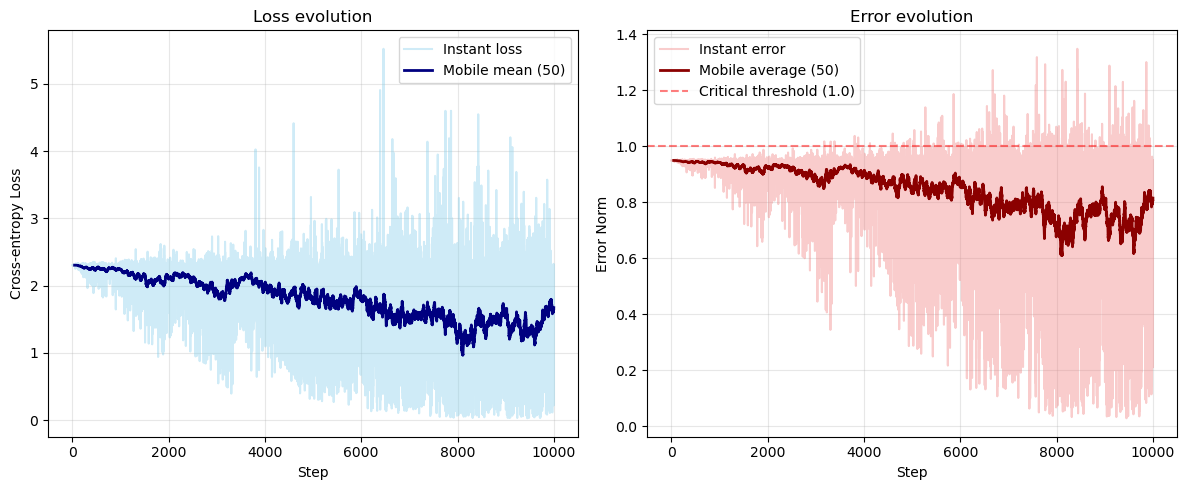

In [40]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocessing import mappixels, onehot, get_active_pixels, downsample_images, canonize_chain, snake_flatten
from src.model import init_single_tensor, contr_lr_tens, contrfin, sweeping, shift_label
from src.utils import plot_train_results, save_checkpoint, load_checkpoint

# ============================================================================
# MODEL PARAMETERS
# ============================================================================
M = 40                                    # Bond dimension
L = 196                                   # Pixel number (14x14)
initpos = L // 2                          # Starting position (98)
numclass = 10                             # 10 classes MNIST
nimg = 10000                              # Image number per training
nepochs= 1
errbuff = 50                              # Buffer error(for average error)

# Gradient descent parameters
learnrate = 7
min_lr= 0.001                              # Learning rate
batchsize = 100                            # Batch size

# Sweeping parameters                     # Starting direction (to the right)
imax = 145                                # Right limit
imin = 50                                 # Left limit
snake = False

# ============================================================================
# DATA LOADING
# ============================================================================
pathX = os.path.join('..', 'data', 'X_mnist.npy')
pathy = os.path.join('..', 'data', 'y_mnist.npy')

X = np.load(pathX)[:nimg]
y = np.load(pathy)[:nimg]

# images scaling 28 X 28 --> 14 X 14
X = downsample_images(X)

# pixel values normalizing [0,255] --> [0,1]
X= X.astype(np.float32) / 255.0

# moving only on pixels with considerable variance
#imin_safe, imax_safe= get_active_pixels(X)
#imin = max(imin_safe, 10)  
#imax = min(imax_safe, 180)
print("Ranging from pixel",imin, imax)

# ============================================================================
# MPS CHAIN INITIALIZING OR LOADING
# ============================================================================

LOAD_EXISTING= False
mps_file = "best_mps_model.pkl"

if LOAD_EXISTING and os.path.exists(mps_file):
    chain, best_loss, actpos, dir_sweep = load_checkpoint(mps_file)
    print(f"🚀 Riprendo da Record: {best_loss:.4f} | Sito: {actpos} | Dir: {dir_sweep}")
else:
    best_loss=float('inf')
    actpos = initpos  # Starting active position (chain center)
    chain = []

    for i in range(L):
        dL = 1 if i == 0 else M
        dR = 1 if i == L-1 else M
        
        if i == initpos:
            t = init_single_tensor(dL, 2, dR, numclass)
        else:
            t = init_single_tensor(dL, 2, dR)
        
        chain.append(t)
    # Setting the Gauge: Transform the MPS into site-canonical form at 'initpos'.
    canonize_chain(chain,L,initpos)

# ============================================================================
# TRAINING VARIABLES INITIALIZATION 
# ============================================================================
errvec= []                                      # Contains error-vec norms
Gacc = np.zeros_like(chain[actpos])             # Cumulated gradient
losses = []                                     # Loss list
history_loss_checkpoints= []                    # Loss history

# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n=== START TRAINING ===\n")

for epoch in range(nepochs):

    #shuffling images index before starting
    indices = np.arange(nimg)
    np.random.shuffle(indices)

    X = X[indices]
    y = y[indices]

    for i in range(nimg):

        # --- Step 1: image preprocessing ---

        imgraw = X[i]
        label = y[i]
        target_onehot = onehot(label, numclass)

        # snake flattening
        if (snake):
            imgsnake=snake_flatten(imgraw)
            imgraw=imgsnake

        # mapping pixels
        imgvec = mappixels(imgraw)  # (L, 2)
    
        # --- Step 2: MPS Contraction ---
        lchain, rchain = contr_lr_tens(chain, imgvec, L, actpos)

        # --- Step 3: Calculating output and softmax ---
        probs, logits = contrfin(lchain, rchain, chain[actpos], imgvec[actpos])


        # --- Step 4: Calcolating error and loss ---

        # Error
        err = probs - target_onehot
        errnorm = np.linalg.norm(err)
        errvec.append(errnorm)
    
        # Cross-entropy loss (-sum(q_i*log(p_i))): ("surprise grade")
        loss = - np.sum(target_onehot * np.log(probs + 1e-12))
        losses.append(loss)

        #Adaptive learn rate based on mean-loss evolution
        if i % 1000 == 0 and i > 3000:

            current_avg = np.mean(losses[-1000:])
    
            if len(history_loss_checkpoints) == 0:
                history_loss_checkpoints.append(current_avg)
            else:
                last_avg = history_loss_checkpoints[-1]
                # If improvement < 0.1% (Plateau)
                if current_avg > last_avg * 0.999:
                    learnrate = max(learnrate * 0.8, min_lr)
                    print(f"\n--- Adaptive LR: {learnrate:.4f} (Plateau detected) ---")
                    
                # If loss worsening (Instabily)
                elif current_avg > last_avg * 1.1:
                    learnrate = max(learnrate * 0.3, min_lr)
                    print(f"\n--- Adaptive LR: {learnrate:.4f} (Divergence detected) ---")
                    # Saving current average for the next check
                history_loss_checkpoints.append(current_avg)
        

        # --- Step 5: Calculating local gradient ---
        # G = left ⊗ p_center ⊗ right ⊗ err
        G = np.einsum('l,p,r,s->lprs', lchain, imgvec[actpos], rchain, err)
        Gacc += G

        #OUTPUT -------------------------------------
        if i % 100 == 0:
            target_prob = probs[label]
            max_logit = np.max(logits)
            min_logit = np.min(logits)
            logit_gap = max_logit - min_logit
            entropy = -np.sum(probs * np.log(probs + 1e-12))
    
            print(f"Step {i:4d} | Loss: {loss:.4f} | Prob Target: {target_prob:.4f} | Logit Max: {max_logit:.2f} | Gap: {logit_gap:.2f} | entropy: {entropy:.2f}")
    
            if max_logit > 30:
                print("⚠️ Warning : Logits too high, saturated softmax!")
        #-----------------------------------------
       
        
        # --- Step 6: Updating parameters (batch) ---
        if (i + 1) % batchsize == 0:

            Gacc /= batchsize
            normGacc = np.linalg.norm(Gacc)

            max_norm= 5.0
            if normGacc > max_norm :
                Gacc = Gacc * (max_norm/normGacc)
    
            # Updating active tensor
            chain[actpos] -= learnrate * Gacc
            
            # Sweeping: moving active index site
            next_pos, next_dir = sweeping(actpos, dir_sweep, imin, imax)

            if next_pos != actpos:

                # moving active site to next position
                chain = shift_label(chain, actpos, dir_sweep, M, imin, imax, i)

                #updating new direction and label position
                actpos = next_pos
                dir_sweep = next_dir
            else:
            # Edge reached! changing direction only
                dir_sweep = next_dir

            # Cumulated gradient reset
            Gacc = np.zeros_like(chain[actpos])        
    
            
current_epoch_loss = np.mean(losses[-1000:]) 

if current_epoch_loss < best_loss:
    best_loss = current_epoch_loss
    save_checkpoint(chain, best_loss, actpos, dir_sweep, mps_file)
    print(f"🔥 New record! Loss: {best_loss:.4f}")
else:
    print(f"⚠️ No improvement (Loss: {current_epoch_loss:.4f} > Best: {best_loss:.4f})")
    save_checkpoint(chain, current_epoch_loss, actpos, dir_sweep, "last_run_backup.pkl")

# ============================================================================
# FINAL RESULT AND PLOTTING 
# ============================================================================
print("\n=== TRAINING COMPLETATO ===")
print(f"Loss media ultimi {errbuff} step: {np.mean(losses[-errbuff:]):.4f}")
print(f"Errore medio ultimi {errbuff} step: {np.mean(errvec[-errbuff:]):.4f}")

plot_train_results(losses, errvec)